In [405]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

def bimodal(S=1, mu=0, sigma=1):
    choose_left = np.random.randint(2, size=S)
    z = np.random.normal(0, sigma, S)
    means = np.where(choose_left == 1, mu - 2, mu + 2)
    if S == 1: return means[0] + z[0]
    return (means + z)

def normal(S=1, mu=0, sigma=1):
    return np.random.normal(mu, sigma, S)

def du_huber(u, k=1.0):
    return np.where(np.abs(u) <= k, u, k * np.sign(u))

runs = 10
N = 32
total_episodes = 50_000
save_skip = 200
learning_rate = 0.04

def run_simple(reward_func, use_huber=False):
    thetas = np.zeros((runs, total_episodes//save_skip, N))
    tau = (np.arange(N) + 0.5) / N
    
    for n in tqdm(range(runs)):
        theta = np.zeros(N)
        lr = learning_rate
        
        for k in range(total_episodes):
            if k % 5000 == 0: lr *= 0.5
            
            target_quantiles = reward_func() + np.zeros(N) # No future state
            
            u = ((target_quantiles[:, None] - theta[None, :])).mean(0)
            
            if use_huber:
                rho = -np.abs(tau - (u < 0)) * du_huber(u)
            else:
                rho = -(tau - (u < 0))
            
            theta -= lr * rho
            
            if k % save_skip == 0: thetas[n, k//save_skip] = theta.copy()
    return thetas

In [378]:
# theta = np.zeros(N)
# tau = (np.arange(N) + 0.5) / N

# def rho(u, i):
#     return -(tau[i] - (u < 0))

# for k in tqdm(range(10_000)):
#     Ttheta = bimodal(1) + np.zeros(N)
    
#     g = np.zeros(N)
#     for i in range(N):
#         for j in range(N):
#             g[i] += rho(Ttheta[j] - theta[i], i) / N
    
#     theta -= (1/(k+1))**0.5 * g

In [406]:
rand_func = bimodal
thetas_run = run_simple(rand_func)
thetas = thetas_run.mean(0)
theta = thetas[-1]

thetas_huber_run = run_simple(rand_func, True)
thetas_huber = thetas_huber_run.mean(0)
theta_huber = thetas_huber[-1]

tau = (np.arange(N) + 0.5) / N
quantized_samples = np.quantile(rand_func(1_000_000), tau)

100%|██████████| 10/10 [00:10<00:00,  1.01s/it]


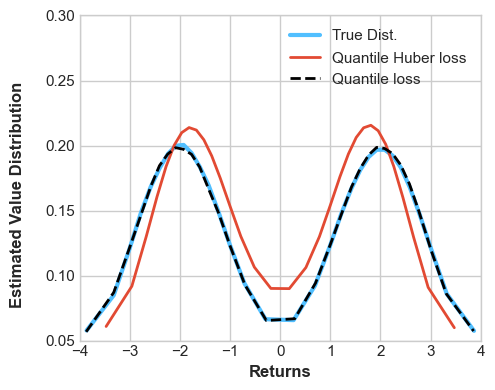

In [ ]:
fig, ax = plt.subplots(figsize=(5,4))
plt.style.use("seaborn-v0_8-whitegrid")
fig.supylabel("Estimated Value Distribution", fontweight="bold")

grad = np.gradient(tau, quantized_samples)
ax.plot(quantized_samples, grad, label="True Dist.", linewidth=3, color="#51BFFF")

grad = np.gradient(tau, theta_huber)
ax.plot(theta_huber, grad, label="Quantile Huber loss", linewidth=2, color="#E24A33")

grad = np.gradient(tau, theta)
ax.plot(theta, grad, label="Quantile loss", linestyle="--", linewidth=2, color="black")

ax.set_xlim(-4,4)
ax.set_ylim(0.05,0.3)
ax.set_xlabel("Returns", fontweight="bold")
ax.legend(loc=1)

plt.tight_layout()
plt.savefig("simple_pdf_compare.pdf", format="pdf", bbox_inches="tight")
plt.show()

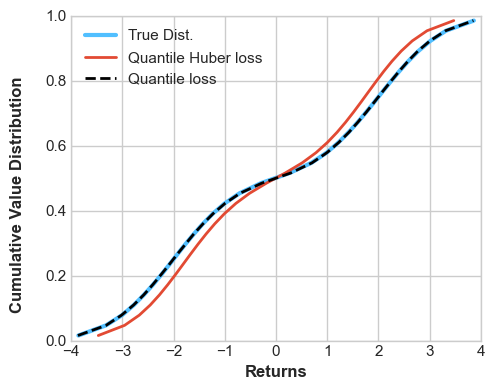

In [423]:
fig, ax = plt.subplots(figsize=(5,4))
plt.style.use("seaborn-v0_8-whitegrid")
fig.supylabel("Cumulative Value Distribution", fontweight="bold")

ax.plot(quantized_samples, tau, label="True Dist.", linewidth=3, color="#51BFFF")
ax.plot(theta_huber, tau, label="Quantile Huber loss", linewidth=2, color="#E24A33")
ax.plot(theta, tau, label="Quantile loss", linestyle="--", linewidth=2, color="black")
ax.set_xlim(-4,4)
ax.set_ylim(0.0,1.0)
ax.set_xlabel("Returns", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("simple_cdf_compare.pdf", format="pdf", bbox_inches="tight")
plt.show()

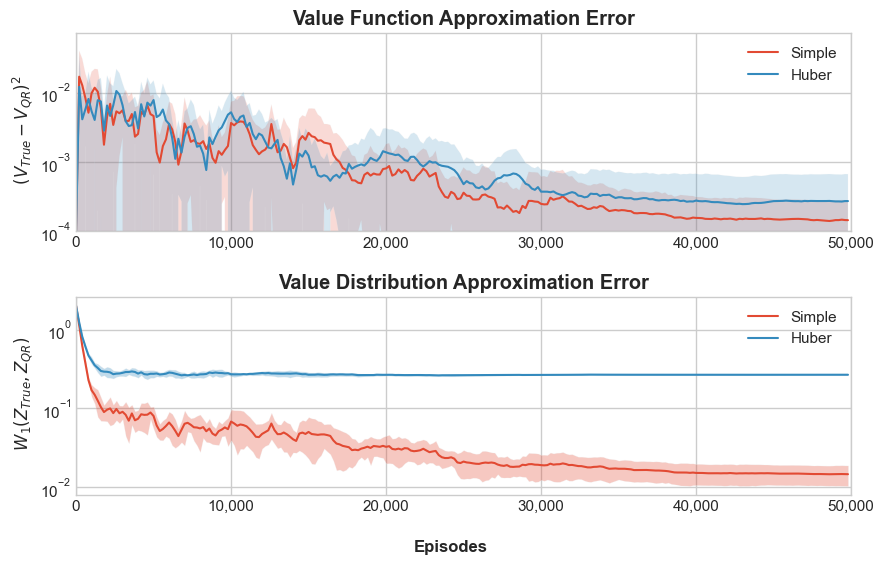

In [428]:
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")
# plt.style.use("ggplot")

fig, axes = plt.subplots(2, 1, figsize=(10,6), gridspec_kw={'hspace': 0.33})
fig.supxlabel("Episodes", fontweight="bold")

# axes[0].set_prop_cycle('color', sns.color_palette())
# axes[1].set_prop_cycle('color', sns.color_palette())

vd = abs(quantized_samples - thetas_run).mean(-1)
vd_hub = abs(quantized_samples - thetas_huber_run).mean(-1)

axes[1].set_title("Value Distribution Approximation Error", fontweight="bold")
axes[1].plot(vd.mean(0), label="Simple")
axes[1].fill_between(range(vd.shape[1]), vd.mean(0) - vd.std(0), vd.mean(0) + vd.std(0), alpha=0.3)

axes[1].plot(vd_hub.mean(0), label="Huber")
axes[1].fill_between(range(vd_hub.shape[1]), vd_hub.mean(0) - vd_hub.std(0), vd_hub.mean(0) + vd_hub.std(0), alpha=0.3)
axes[1].set_yscale("log")

ticks = axes[1].get_xticks().astype(int)
axes[1].set_xticks(ticks, [f"{x:,}" for x in ticks*save_skip])
axes[1].set_xlim(ticks[1], ticks[-2])
axes[1].legend(loc=1)

vf = (quantized_samples.mean()-thetas_run.mean(-1))**2
vf_hub = (quantized_samples.mean()-thetas_huber_run.mean(-1))**2

axes[0].set_title("Value Function Approximation Error", fontweight="bold")
axes[0].plot(vf.mean(0), label="Simple")
axes[0].fill_between(range(vf.shape[1]), vf.mean(0) - vf.std(0), vf.mean(0) + vf.std(0), alpha=0.2)

axes[0].plot(vf_hub.mean(0), label="Huber")
axes[0].fill_between(range(vf_hub.shape[1]), vf_hub.mean(0) - vf_hub.std(0), vf_hub.mean(0) + vf_hub.std(0), alpha=0.2)
axes[0].set_yscale("log")

axes[0].set_xticks(ticks, [f"{x:,}" for x in ticks*save_skip])
axes[0].set_xlim(ticks[1], ticks[-2])
axes[0].legend(loc=1)

axes[0].set_ylim(1e-4)
axes[1].set_ylabel(" $ W_1(Z_{True}, Z_{QR}) $")
axes[0].set_ylabel(" $ (V_{True} - V_{QR} )^2 $")

plt.savefig("simple_true_compare.pdf", format="pdf", bbox_inches="tight")
plt.show()